In [ ]:
!git clone https://github.com/nianticlabs/monodepth2

Cloning into 'monodepth2'...
remote: Enumerating objects: 180, done.
remote: Total 180 (delta 0), reused 0 (delta 0), pack-reused 180
Receiving objects: 100% (180/180), 10.27 MiB | 21.59 MiB/s, done.
Resolving deltas: 100% (89/89), done.


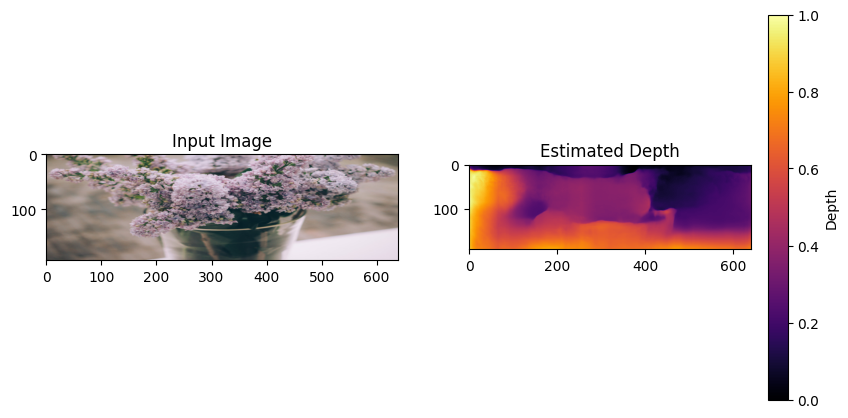

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

# Append the path to the Monodepth2 repository
sys.path.append("/content/monodepth2")  # Replace with the actual path to the monodepth2 directory

from monodepth2 import networks

# Function to load an image from a local file
def load_image(file_path):
    img = Image.open(file_path).convert('RGB')
    return img

# Load a sample image
image_path = "/content/test1.jpg"  # Replace with your local image path
input_image = load_image(image_path)

# Preprocessing the image
input_image = input_image.resize((640, 192), Image.LANCZOS)
transform = transforms.ToTensor()
input_tensor = transform(input_image).unsqueeze(0)

# Load the pretrained Monodepth2 model
encoder_path = "/content/monodepth2/encoder.pth"  # Adjust the path accordingly
depth_decoder_path = "/content/monodepth2/depth.pth"  # Adjust the path accordingly

encoder = networks.ResnetEncoder(18, False)
depth_decoder = networks.DepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))

loaded_dict_enc = torch.load(encoder_path, map_location=torch.device('cpu'))
filtered_dict_enc = {k: v for k, v in loaded_dict_enc.items() if k in encoder.state_dict()}
encoder.load_state_dict(filtered_dict_enc)

loaded_dict = torch.load(depth_decoder_path, map_location=torch.device('cpu'))
depth_decoder.load_state_dict(loaded_dict)

encoder.eval()
depth_decoder.eval()

# Perform inference
with torch.no_grad():
    features = encoder(input_tensor)
    outputs = depth_decoder(features)

depth_map = outputs[("disp", 0)]
depth_map = depth_map.squeeze().cpu().numpy()
depth_map = np.interp(depth_map, (depth_map.min(), depth_map.max()), (0, 1))

# Visualizing the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Input Image')
plt.imshow(input_image)

plt.subplot(1, 2, 2)
plt.title('Estimated Depth')
plt.imshow(depth_map, cmap='inferno')
plt.colorbar(label='Depth')

plt.show()

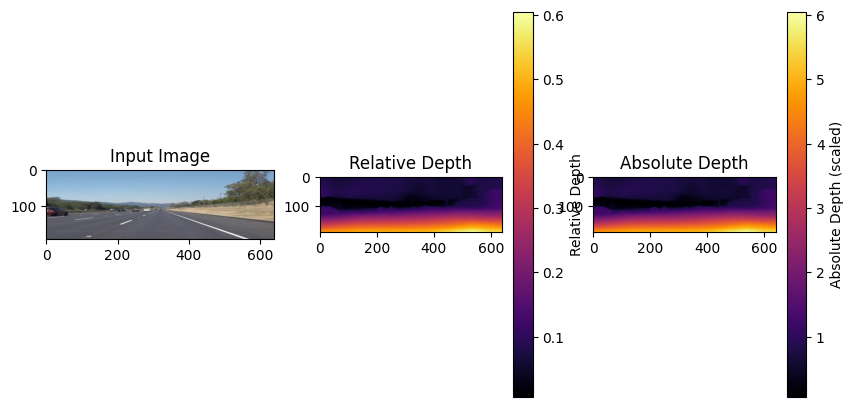

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

# Append the path to the Monodepth2 repository
sys.path.append("/content/monodepth2")  # Replace with the actual path to the monodepth2 directory

from monodepth2 import networks

# Function to load an image from a local file
def load_image(file_path):
    img = Image.open(file_path).convert('RGB')
    return img

# Load a sample image
image_path = "/content/solidWhiteRight.jpg"  # Replace with your local image path
input_image = load_image(image_path)

# Preprocessing the image
input_image = input_image.resize((640, 192), Image.LANCZOS)
transform = transforms.ToTensor()
input_tensor = transform(input_image).unsqueeze(0)

# Load the pretrained Monodepth2 model
encoder_path = "/content/monodepth2/encoder.pth"  # Adjust the path accordingly
depth_decoder_path = "/content/monodepth2/depth.pth"  # Adjust the path accordingly

encoder = networks.ResnetEncoder(18, False)
depth_decoder = networks.DepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))

loaded_dict_enc = torch.load(encoder_path, map_location=torch.device('cpu'))
filtered_dict_enc = {k: v for k, v in loaded_dict_enc.items() if k in encoder.state_dict()}
encoder.load_state_dict(filtered_dict_enc)

loaded_dict = torch.load(depth_decoder_path, map_location=torch.device('cpu'))
depth_decoder.load_state_dict(loaded_dict)

encoder.eval()
depth_decoder.eval()

# Perform inference
with torch.no_grad():
    features = encoder(input_tensor)
    outputs = depth_decoder(features)

depth_map = outputs[("disp", 0)]
depth_map = depth_map.squeeze().cpu().numpy()

# Apply scale factor to get absolute depth (example scale factor: 10)
scale_factor = 10
absolute_depth_map = depth_map * scale_factor

# Visualizing the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title('Input Image')
plt.imshow(input_image)

plt.subplot(1, 3, 2)
plt.title('Relative Depth')
plt.imshow(depth_map, cmap='inferno')
plt.colorbar(label='Relative Depth')

plt.subplot(1, 3, 3)
plt.title('Absolute Depth')
plt.imshow(absolute_depth_map, cmap='inferno')
plt.colorbar(label='Absolute Depth (scaled)')

plt.show()
